In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


import time
import math
import random
import re
import os
import sys


from utils.util import find_files_with_extension
from utils.util import  get_dataframe_from_filepath,calculate_statistics, extract_unique_mbps_and_ms
from utils.util import remove_outliers_iqr, comma_format, create_directory_if_not_exists,print_rtt_stats,save_rtt_stats,return_rtt_stats

In [2]:
# Load data
mainpth="../data/tcp_data_2025-04-11"

graph_directory = os.path.join(mainpth, "Graphs")
create_directory_if_not_exists(graph_directory)

stats_directory = os.path.join(mainpth, "Stats")
create_directory_if_not_exists(stats_directory)


folderpaths = [mainpth+'/client1_data',mainpth+'/client2_data']
filenames, filepaths, filedict = find_files_with_extension(folderpaths, '.log')


Directory already exists: ../data/tcp_data_2025-04-11\Graphs
Directory already exists: ../data/tcp_data_2025-04-11\Stats


In [3]:
filedict

{'1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log': '../data/tcp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log': '../data/tcp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log': '../data/tcp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log': '../data/tcp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log': '../data/tcp_data_2025-04-11/client1_data\\1_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log': '../data/tcp_data_2025-04-11/client1_data\\1_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_10Mbps_20ms_ecn_tcp_newreno_src1.siftr.log': '../data/tc

In [4]:
folderpaths

['../data/tcp_data_2025-04-11/client1_data',
 '../data/tcp_data_2025-04-11/client2_data']

In [5]:
# Call the function and print unique combinations
unique_combinations = extract_unique_mbps_and_ms(folderpaths)
print("Unique Mbps and ms Combinations:")
for mbps, ms in sorted(unique_combinations):
    print(f'{mbps} Mbps, {ms} ms')


Unique Mbps and ms Combinations:
10 Mbps, 0 ms
10 Mbps, 10 ms
10 Mbps, 20 ms
10 Mbps, 5 ms
100 Mbps, 0 ms
100 Mbps, 10 ms
100 Mbps, 20 ms
100 Mbps, 5 ms
150 Mbps, 0 ms
150 Mbps, 10 ms
150 Mbps, 20 ms
150 Mbps, 5 ms
20 Mbps, 0 ms
20 Mbps, 10 ms
20 Mbps, 20 ms
20 Mbps, 5 ms


In [6]:
mbps , ms = list(unique_combinations)[0]
net_settings = f'{mbps}_Mbps_{ms}_ms'
print(net_settings)

10_Mbps_5_ms


In [7]:
df=get_dataframe_from_filepath(filepaths[0])
df['ForeignPort'].unique()

../data/tcp_data_2025-04-11/client1_data\1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log


array(['53854', '53781', '53787', '53789', '5102', '5101', '50478'],
      dtype=object)

In [ ]:
# unique_scenarios_dict={}
# for index in range(len(filenames)):
#     scenario = "_".join(filenames[index].split('_')[:5])
#     print(scenario)
#     print("_".join(filenames[index].split('_')[:4]))

1_dualpi2_100Mbps_0ms_ecn
1_dualpi2_100Mbps_0ms
1_dualpi2_100Mbps_10ms_ecn
1_dualpi2_100Mbps_10ms
1_dualpi2_100Mbps_20ms_ecn
1_dualpi2_100Mbps_20ms
1_dualpi2_100Mbps_5ms_ecn
1_dualpi2_100Mbps_5ms
1_dualpi2_10Mbps_0ms_ecn
1_dualpi2_10Mbps_0ms
1_dualpi2_10Mbps_10ms_ecn
1_dualpi2_10Mbps_10ms
1_dualpi2_10Mbps_20ms_ecn
1_dualpi2_10Mbps_20ms
1_dualpi2_10Mbps_5ms_ecn
1_dualpi2_10Mbps_5ms
1_dualpi2_150Mbps_0ms_ecn
1_dualpi2_150Mbps_0ms
1_dualpi2_150Mbps_10ms_ecn
1_dualpi2_150Mbps_10ms
1_dualpi2_150Mbps_20ms_ecn
1_dualpi2_150Mbps_20ms
1_dualpi2_150Mbps_5ms_ecn
1_dualpi2_150Mbps_5ms
1_dualpi2_20Mbps_0ms_ecn
1_dualpi2_20Mbps_0ms
1_dualpi2_20Mbps_10ms_ecn
1_dualpi2_20Mbps_10ms
1_dualpi2_20Mbps_20ms_ecn
1_dualpi2_20Mbps_20ms
1_dualpi2_20Mbps_5ms_ecn
1_dualpi2_20Mbps_5ms
2_dualpi2_100Mbps_0ms_ecn
2_dualpi2_100Mbps_0ms
2_dualpi2_100Mbps_10ms_ecn
2_dualpi2_100Mbps_10ms
2_dualpi2_100Mbps_20ms_ecn
2_dualpi2_100Mbps_20ms
2_dualpi2_100Mbps_5ms_ecn
2_dualpi2_100Mbps_5ms
2_dualpi2_10Mbps_0ms_ecn
2_dualpi2_1

In [15]:
unique_scenarios_dict={}
for index in range(len(filenames)):
    scenario = "_".join(filenames[index].split('_')[:6])
    if "dualpi2" in scenario or "l4s" in scenario:
        scenario = "_".join(filenames[index].split('_')[:5])
    if scenario in unique_scenarios_dict:
        unique_scenarios_dict[scenario].append(filedict[filenames[index]])
    else:
        unique_scenarios_dict[scenario]=[filedict[filenames[index]]]


In [16]:
unique_scenarios_dict

{'1_dualpi2_100Mbps_0ms_ecn': ['../data/tcp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log',
  '../data/tcp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_10ms_ecn': ['../data/tcp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log',
  '../data/tcp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_20ms_ecn': ['../data/tcp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log',
  '../data/tcp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_5ms_ecn': ['../data/tcp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log',
  '../data/tcp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log'],
 '1_dualpi2_10Mbps_0ms_ecn': ['../data/tcp_data_2025-04-11/client1_data\\1_dualpi2

In [16]:
from utils.plotter import  plot_siftr_graph


Start New Scenario
1_dualpi2_100Mbps_0ms_ecn
../data/tcp_data_2025-04-11/client1_data\1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/tcp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_100Mbps_0ms_ecn:
Statistics for CUBIC:
Median: 26.875
Mean: 37.64467111146179
25th Percentile: 22.187
75th Percentile: 30.937
Minimum: 3.125
Maximum: 328.125
Statistics for NEWRENO:
Median: 26.562
Mean: 27.055373964261708
25th Percentile: 22.187
75th Percentile: 30.0
Minimum: 2.187
Maximum: 315.0
Statistics for DCTCP:
Median: 24.375
Mean: 27.723504895151596
25th Percentile: 20.0
75th Percentile: 29.687
Minimum: 2.187
Maximum: 319.687
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/tcp_data_2025-04-11\Stats/scn_1_dualpi2_100Mbps_0ms_ecn_rtt_stats.txt



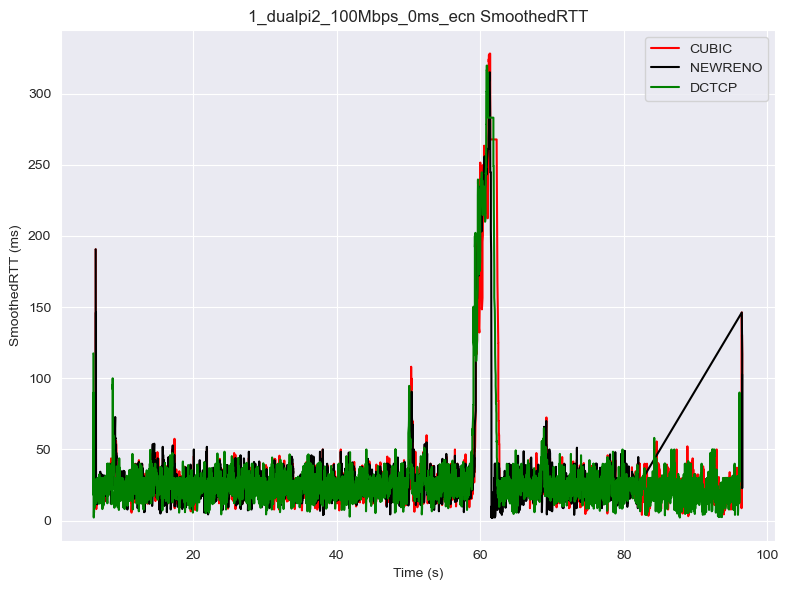

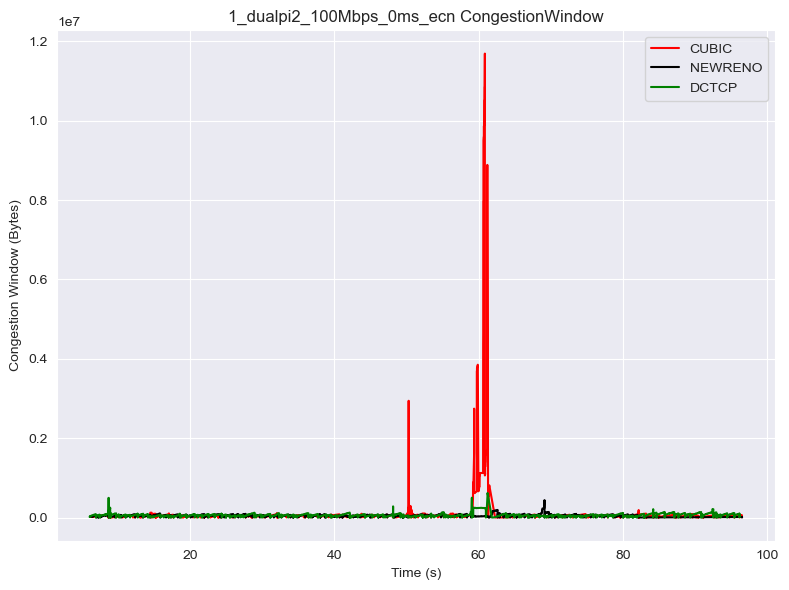


Start New Scenario
1_dualpi2_100Mbps_10ms_ecn
../data/tcp_data_2025-04-11/client1_data\1_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/tcp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_100Mbps_10ms_ecn:
Statistics for CUBIC:
Median: 200.0
Mean: 182.4254190186951
25th Percentile: 145.625
75th Percentile: 220.0
Minimum: 32.187
Maximum: 423.75
Statistics for NEWRENO:
Median: 160.0
Mean: 155.60766720991376
25th Percentile: 98.437
75th Percentile: 212.187
Minimum: 35.937
Maximum: 415.937
Statistics for DCTCP:
Median: 172.5
Mean: 161.76990583307358
25th Percentile: 103.125
75th Percentile: 211.25
Minimum: 33.75
Maximum: 420.0
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/tcp_data_2025-04-11\Stats/scn_1_dualpi2_100Mbps_10ms_ecn_rtt_stats.txt



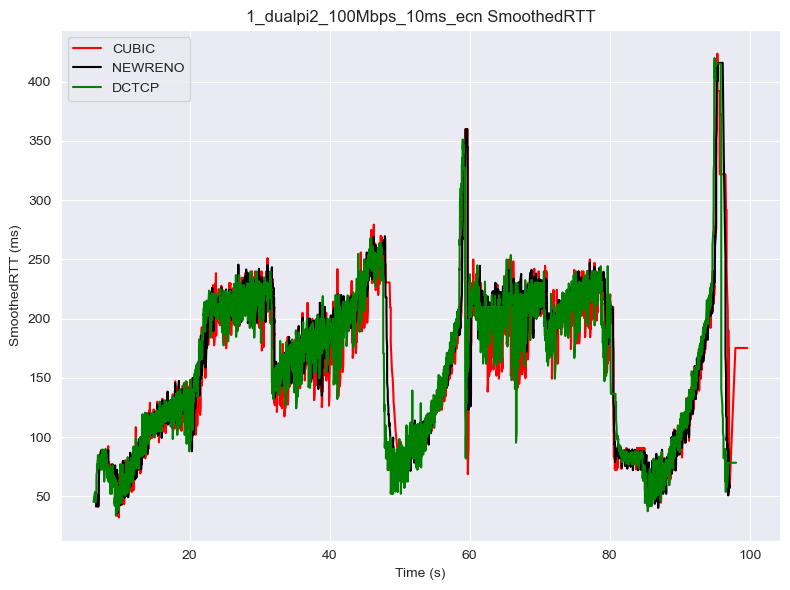

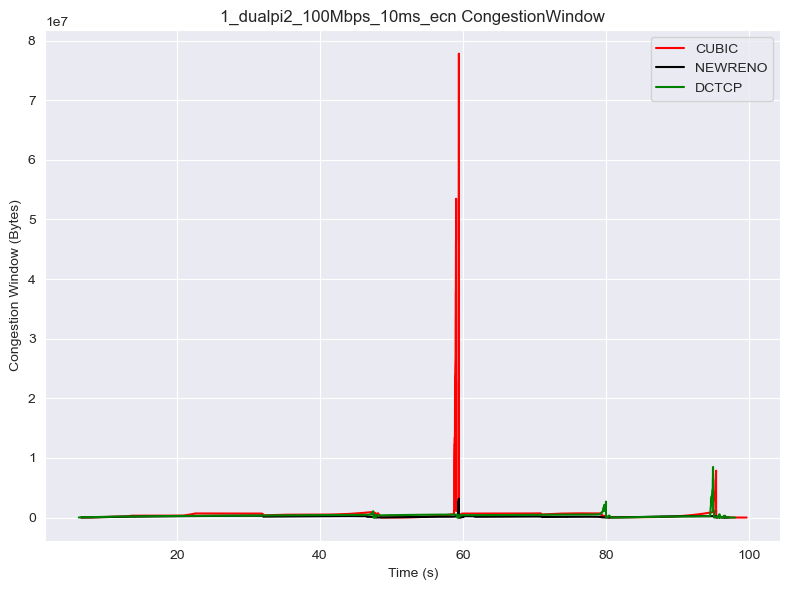


Start New Scenario
1_dualpi2_100Mbps_20ms_ecn
../data/tcp_data_2025-04-11/client1_data\1_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
../data/tcp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_100Mbps_20ms_ecn:
Statistics for CUBIC:
Median: 202.187
Mean: 203.56901919962226
25th Percentile: 167.187
75th Percentile: 241.562
Minimum: 78.75
Maximum: 392.812
Statistics for NEWRENO:
Median: 197.187
Mean: 193.16471109969606
25th Percentile: 170.0
75th Percentile: 212.187
Minimum: 78.75
Maximum: 376.562
Statistics for DCTCP:
Median: 208.437
Mean: 210.39193143770743
25th Percentile: 182.187
75th Percentile: 242.187
Minimum: 66.25
Maximum: 390.0
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/tcp_data_2025-04-11\Stats/scn_1_dualpi2_100Mbps_20ms_ecn_rtt_stats.txt



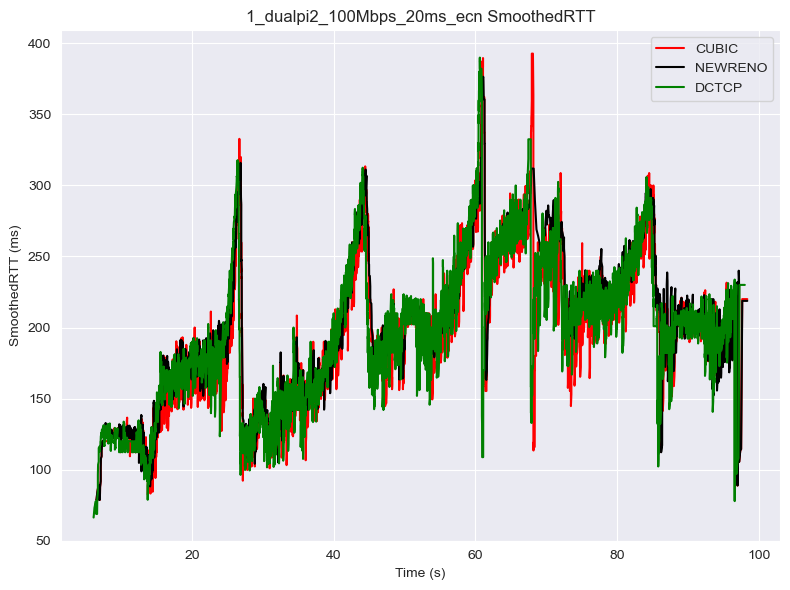

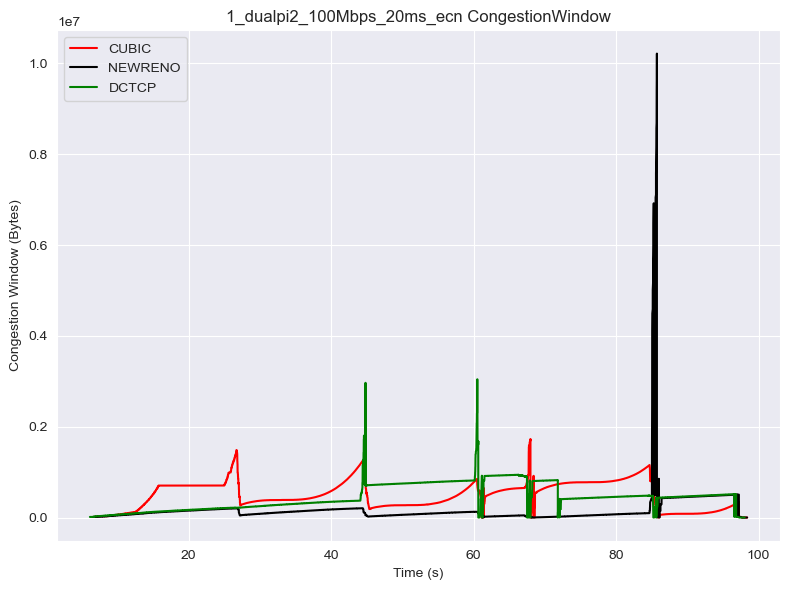


Start New Scenario
1_dualpi2_100Mbps_5ms_ecn
../data/tcp_data_2025-04-11/client1_data\1_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
../data/tcp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_100Mbps_5ms_ecn:
Statistics for CUBIC:
Median: 28.75
Mean: 60.473290367607085
25th Percentile: 23.437
75th Percentile: 38.125
Minimum: 4.375
Maximum: 378.75
Statistics for NEWRENO:
Median: 27.187
Mean: 35.77725575964588
25th Percentile: 22.187
75th Percentile: 31.25
Minimum: 2.187
Maximum: 387.187
Statistics for DCTCP:
Median: 58.75
Mean: 100.98008446358645
25th Percentile: 25.625
75th Percentile: 190.0
Minimum: 2.187
Maximum: 370.0
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/tcp_data_2025-04-11\Stats/scn_1_dualpi2_100Mbps_5ms_ecn_rtt_stats.txt



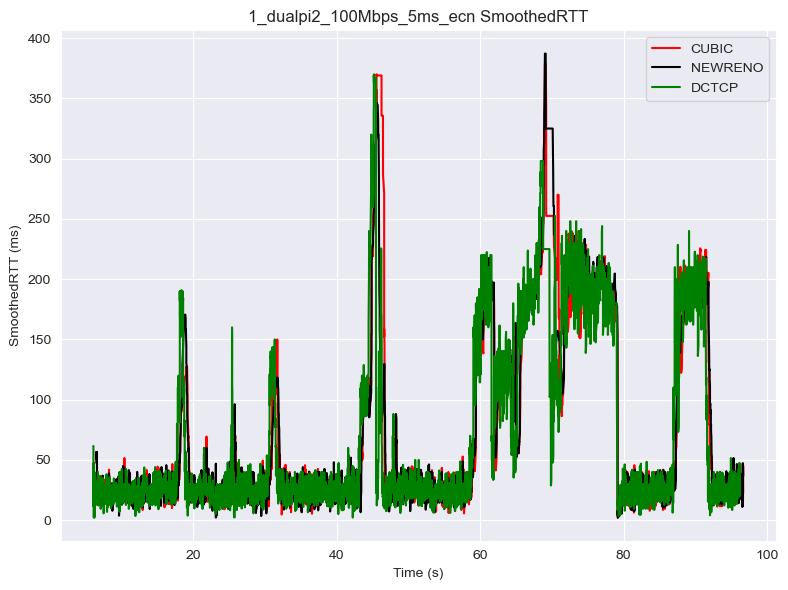

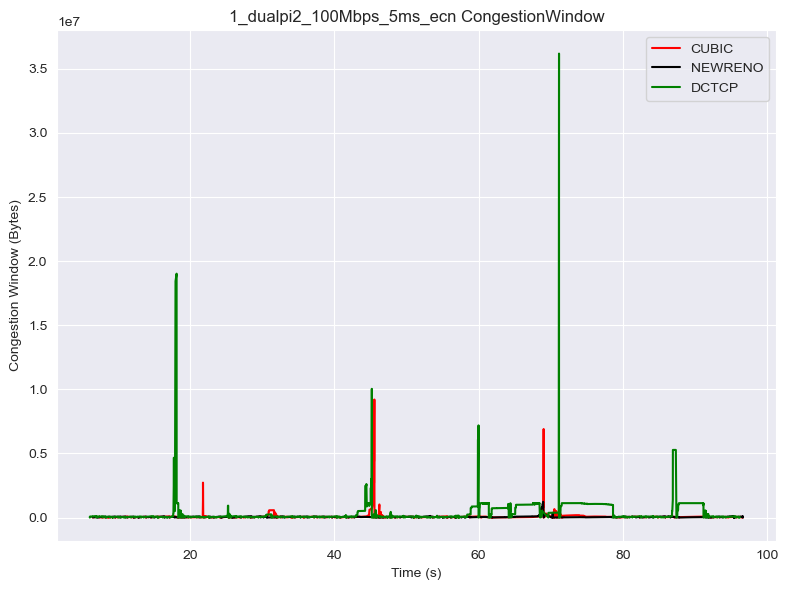


Start New Scenario
1_dualpi2_10Mbps_0ms_ecn
../data/tcp_data_2025-04-11/client1_data\1_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/tcp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_10Mbps_0ms_ecn:
Statistics for CUBIC:
Median: 201.562
Mean: 196.53659586244441
25th Percentile: 88.437
75th Percentile: 287.812
Minimum: 6.562
Maximum: 548.125
Statistics for NEWRENO:
Median: 198.75
Mean: 192.30848265831278
25th Percentile: 116.875
75th Percentile: 252.812
Minimum: 26.875
Maximum: 500.0
Statistics for DCTCP:
Median: 180.0
Mean: 193.52544584535923
25th Percentile: 108.437
75th Percentile: 270.0
Minimum: 35.0
Maximum: 486.25
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/tcp_data_2025-04-11\Stats/scn_1_dualpi2_10Mbps_0ms_ecn_rtt_stats.txt



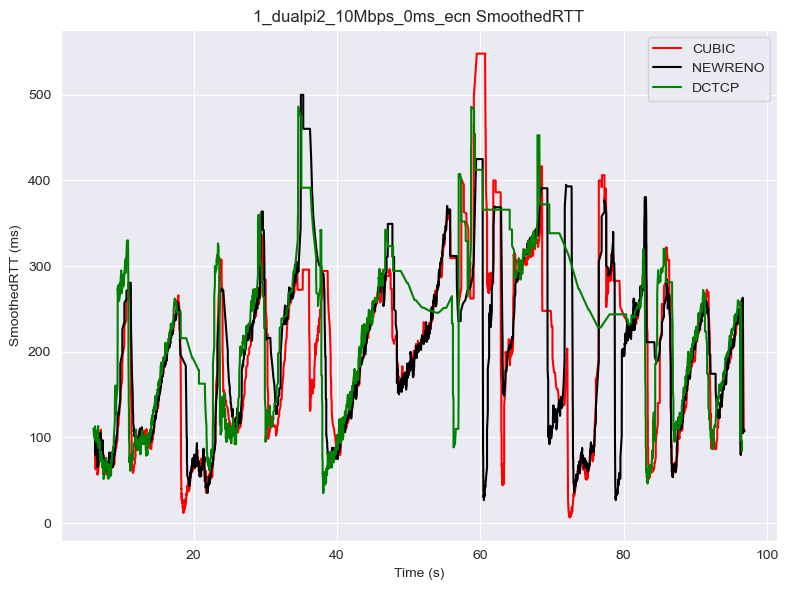

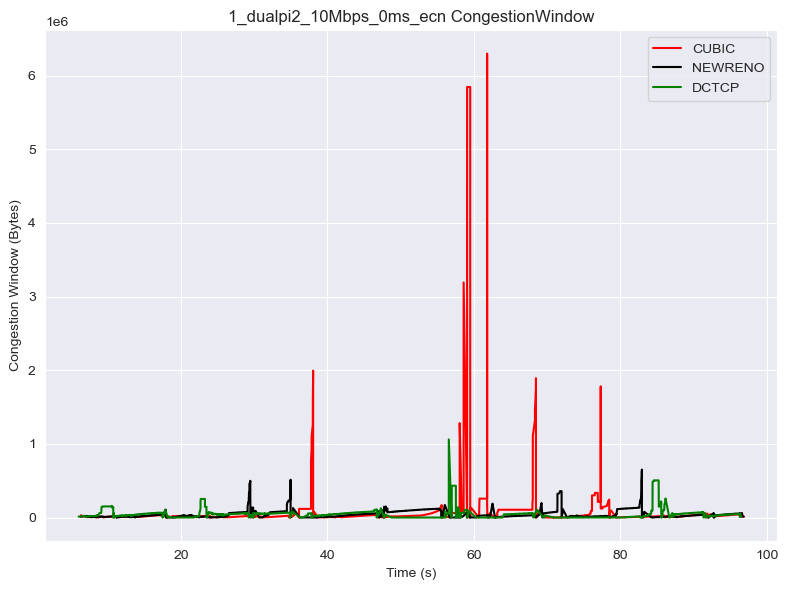


Start New Scenario
1_dualpi2_10Mbps_10ms_ecn
../data/tcp_data_2025-04-11/client1_data\1_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/tcp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_10Mbps_10ms_ecn:
Statistics for CUBIC:
Median: 267.9685
Mean: 263.83386559269053
25th Percentile: 220.0
75th Percentile: 309.687
Minimum: 88.75
Maximum: 480.625
Statistics for NEWRENO:
Median: 245.625
Mean: 246.44769545506063
25th Percentile: 192.9685
75th Percentile: 299.687
Minimum: 60.937
Maximum: 464.062
Statistics for DCTCP:
Median: 257.5
Mean: 262.8108508382145
25th Percentile: 210.0
75th Percentile: 314.062
Minimum: 71.25
Maximum: 454.687
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/tcp_data_2025-04-11\Stats/scn_1_dualpi2_10Mbps_10ms_ecn_rtt_stats.txt



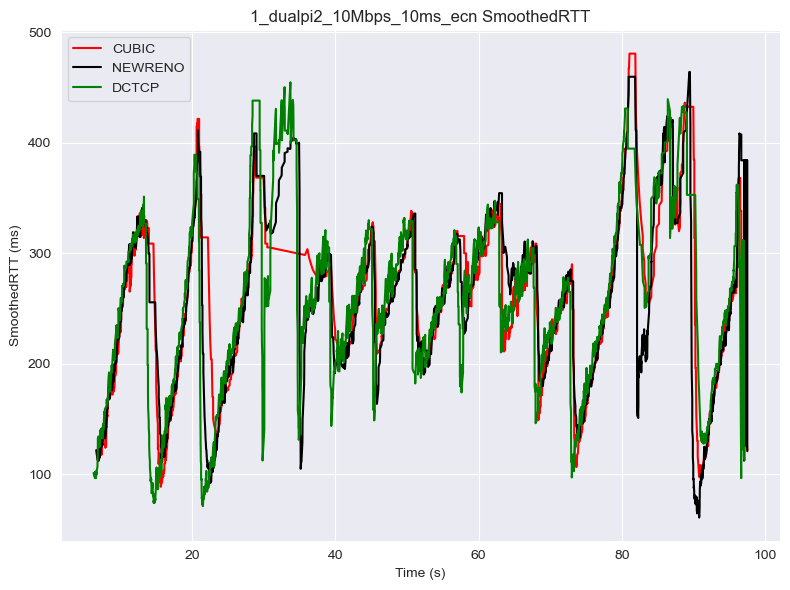

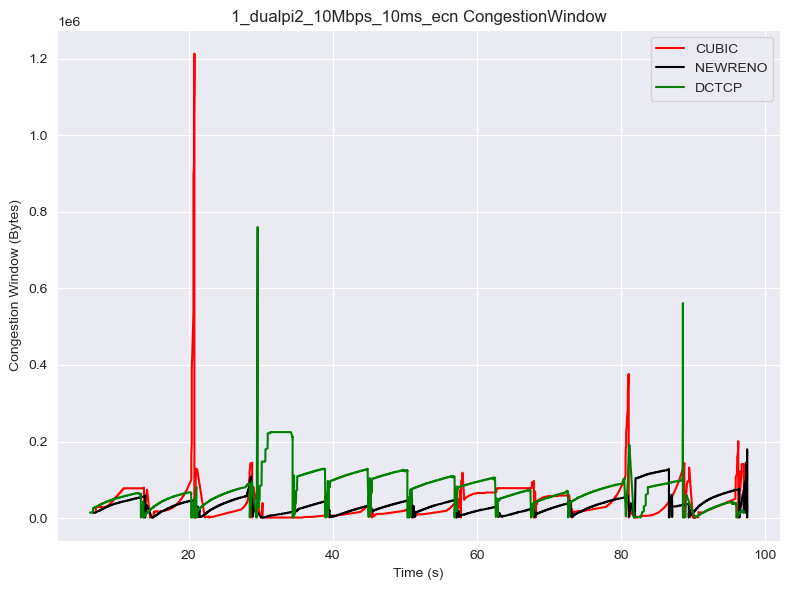


Start New Scenario
1_dualpi2_10Mbps_20ms_ecn
../data/tcp_data_2025-04-11/client1_data\1_dualpi2_10Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
../data/tcp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_10Mbps_20ms_ecn:
Statistics for CUBIC:
Median: 273.125
Mean: 279.9746077560434
25th Percentile: 216.25
75th Percentile: 327.187
Minimum: 115.937
Maximum: 621.25
Statistics for NEWRENO:
Median: 276.875
Mean: 288.1333515930687
25th Percentile: 227.187
75th Percentile: 338.125
Minimum: 119.375
Maximum: 578.437
Statistics for DCTCP:
Median: 305.0
Mean: 305.7144723555943
25th Percentile: 243.125
75th Percentile: 362.187
Minimum: 129.687
Maximum: 607.812
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/tcp_data_2025-04-11\Stats/scn_1_dualpi2_10Mbps_20ms_ecn_rtt_stats.txt



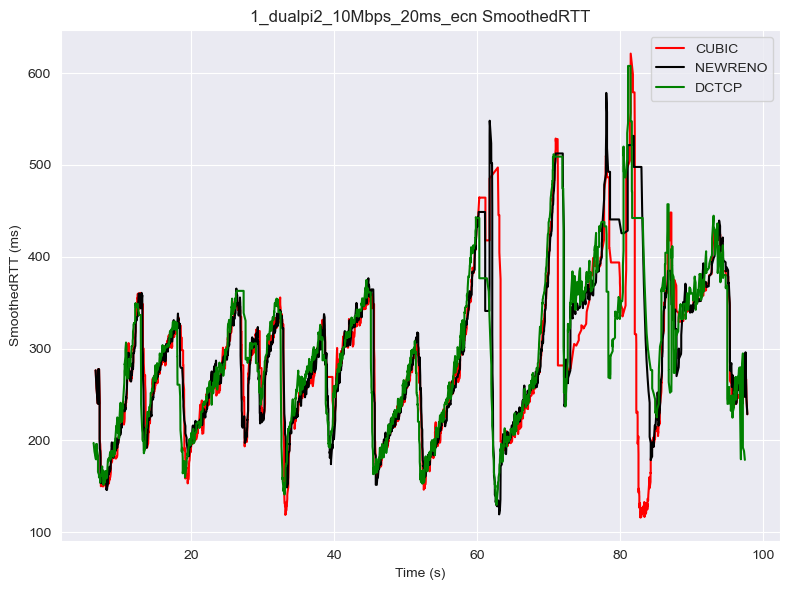

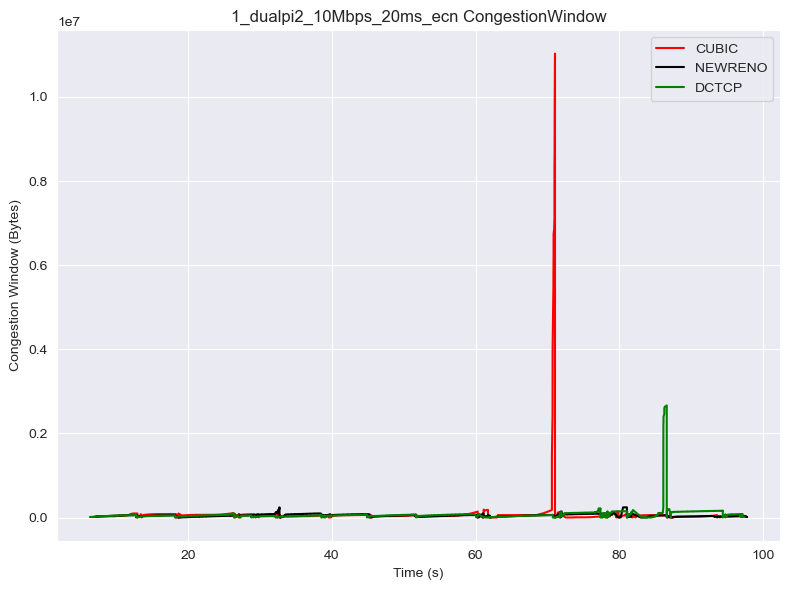


Start New Scenario
1_dualpi2_10Mbps_5ms_ecn
../data/tcp_data_2025-04-11/client1_data\1_dualpi2_10Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
../data/tcp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_10Mbps_5ms_ecn:
Statistics for CUBIC:
Median: 201.562
Mean: 196.26858188715028
25th Percentile: 109.687
75th Percentile: 249.687
Minimum: 22.187
Maximum: 672.5
Statistics for NEWRENO:
Median: 183.75
Mean: 192.67098301642974
25th Percentile: 86.875
75th Percentile: 250.312
Minimum: 25.937
Maximum: 530.0
Statistics for DCTCP:
Median: 191.25
Mean: 195.4470812826249
25th Percentile: 118.437
75th Percentile: 240.625
Minimum: 21.25
Maximum: 511.25
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/tcp_data_2025-04-11\Stats/scn_1_dualpi2_10Mbps_5ms_ecn_rtt_stats.txt



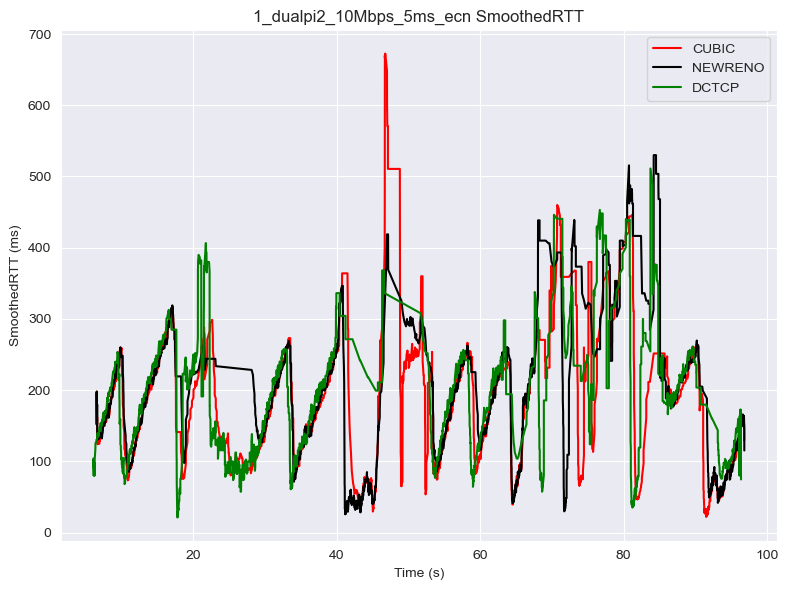

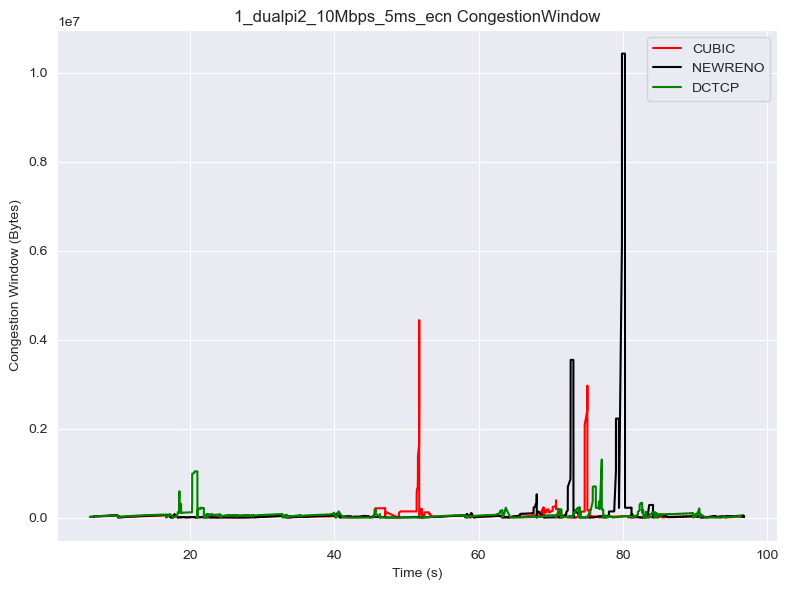


Start New Scenario
1_dualpi2_150Mbps_0ms_ecn
../data/tcp_data_2025-04-11/client1_data\1_dualpi2_150Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/tcp_data_2025-04-11/client2_data\1_dualpi2_150Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_150Mbps_0ms_ecn:
Statistics for CUBIC:
Median: 37.187
Mean: 95.68866269606532
25th Percentile: 21.562
75th Percentile: 179.062
Minimum: 2.187
Maximum: 420.0
Statistics for NEWRENO:
Median: 23.437
Mean: 46.808893258501236
25th Percentile: 17.812
75th Percentile: 30.0
Minimum: 2.187
Maximum: 400.625
Statistics for DCTCP:
Median: 27.812
Mean: 72.71736858754166
25th Percentile: 19.687
75th Percentile: 108.437
Minimum: 2.187
Maximum: 420.0
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/tcp_data_2025-04-11\Stats/scn_1_dualpi2_150Mbps_0ms_ecn_rtt_stats.txt



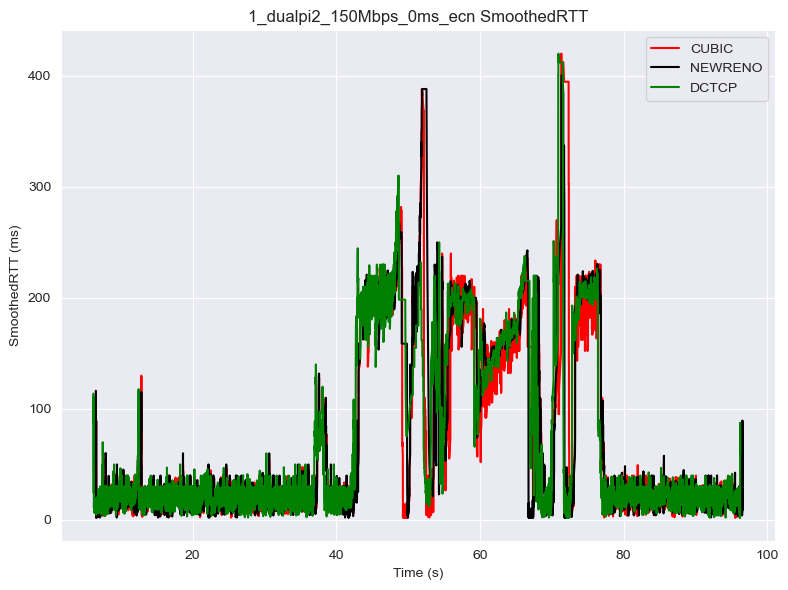

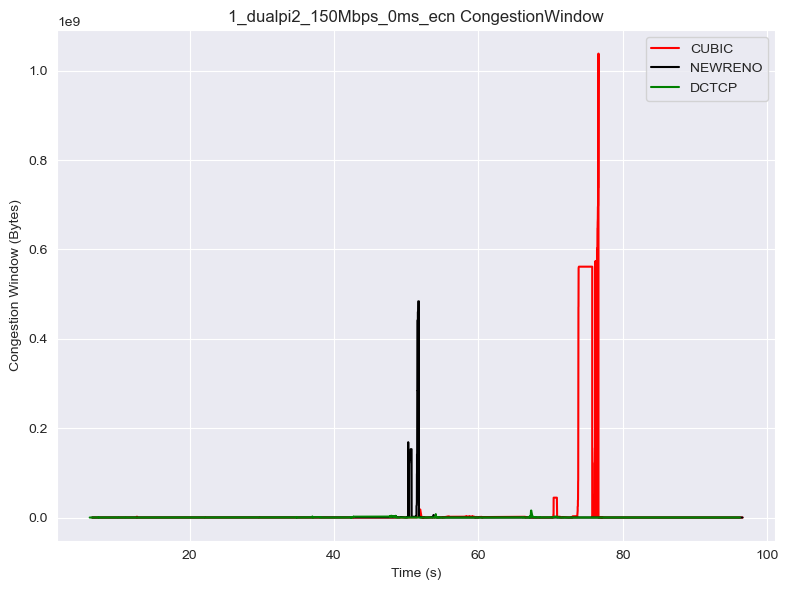


Start New Scenario
1_dualpi2_150Mbps_10ms_ecn
../data/tcp_data_2025-04-11/client1_data\1_dualpi2_150Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/tcp_data_2025-04-11/client2_data\1_dualpi2_150Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_150Mbps_10ms_ecn:
Statistics for CUBIC:
Median: 130.0
Mean: 136.456349442255
25th Percentile: 106.25
75th Percentile: 171.25
Minimum: 35.312
Maximum: 237.5
Statistics for NEWRENO:
Median: 120.0
Mean: 124.66573331473803
25th Percentile: 95.625
75th Percentile: 151.875
Minimum: 33.125
Maximum: 235.0
Statistics for DCTCP:
Median: 129.687
Mean: 130.4171381881689
25th Percentile: 100.0
75th Percentile: 160.0
Minimum: 32.187
Maximum: 237.812
END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*END RTT *-*-*


Saving RTT statistics in millisecond (ms) to ../data/tcp_data_2025-04-11\Stats/scn_1_dualpi2_150Mbps_10ms_ecn_rtt_stats.txt



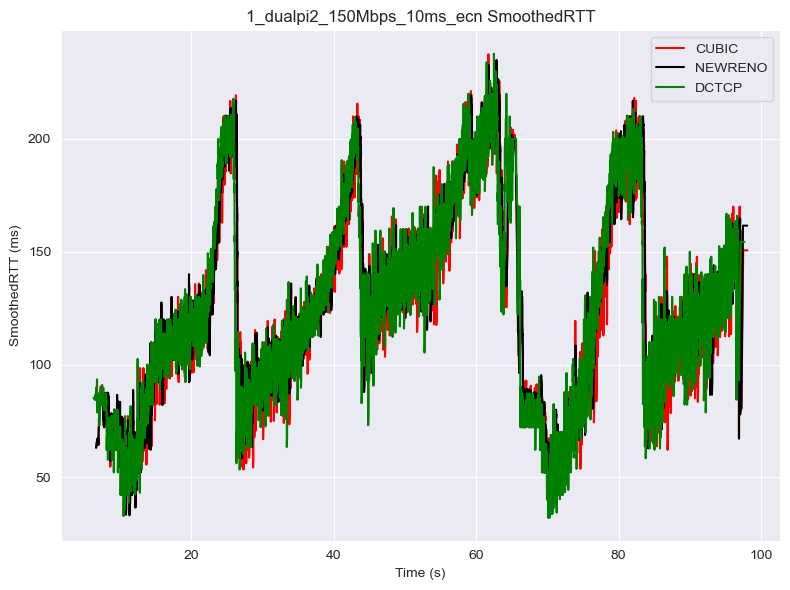

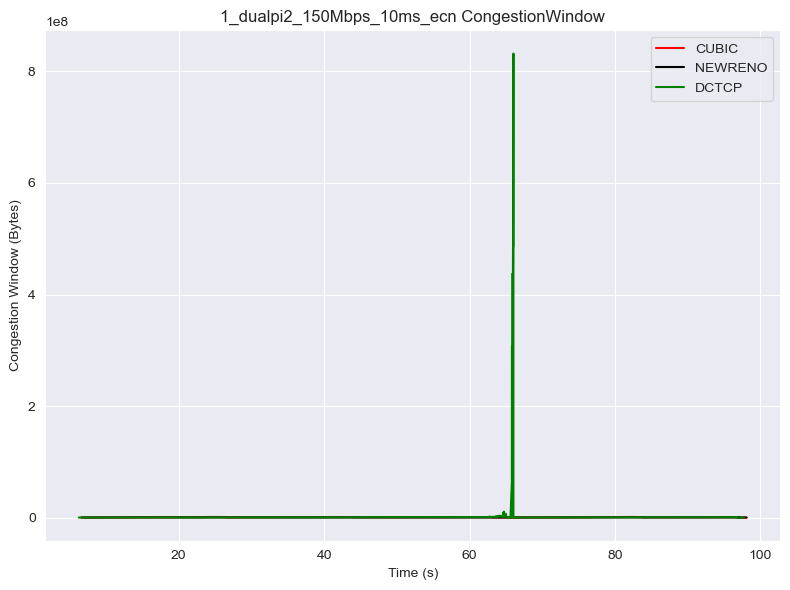


Start New Scenario
1_dualpi2_150Mbps_20ms_ecn


In [ ]:
for scenario in unique_scenarios_dict.keys():

    tcp1 = "CUBIC"
    tcp2 = "NEWRENO"
    tcp3 = "DCTCP"
    print()
    print("Start New Scenario")
    print(scenario)

    classif_traffic = unique_scenarios_dict[scenario][0]
    l4s_traffic = unique_scenarios_dict[scenario][1]

    ctf = get_dataframe_from_filepath(classif_traffic)
    ltf = get_dataframe_from_filepath(l4s_traffic)

    ctf1 = ctf[ctf['ForeignPort'] == "5101"]
    ctf2 = ctf[ctf['ForeignPort'] == "5102"]
    ltf =  ltf[ltf['ForeignPort'] == "5103"]

    # Define paths
    paths = {
        tcp1: ctf1,
        tcp2: ctf2,
        tcp3: ltf,
    }

    print_rtt_stats(paths=paths,scenario=scenario)
    save_rtt_stats(paths=paths,scenario=scenario,stats_directory=stats_directory)



    plot_siftr_graph(paths=paths,
                    ycolumn="SmoothedRTT",
                    title=f"{scenario} SmoothedRTT",
                    xlabel="Time (s)",
                    ylabel="SmoothedRTT (ms)",
                    filename=f'{scenario}_SmoothedRTT',
                    graph_directory=graph_directory,
    )




    plot_siftr_graph(paths=paths,
                    ycolumn="CongestionWindow",
                    title=f"{scenario} CongestionWindow",
                    xlabel="Time (s)",
                    ylabel="Congestion Window (Bytes)",
                    filename=f'{scenario}_CWND',
                    graph_directory=graph_directory,
    )
